# UN Comtrade — Sri Lanka export data

The only one of CeyNex's six data sources that is fully built and populated
(see `ceynex-core/docs/DATA_SOURCES.md`). Data is Sri Lanka's (UN country 144)
exports of five HS product codes — tea (0902), cinnamon (0906), natural
rubber (4001), knitted apparel (61), woven apparel (62) — for 2015-2024,
downloaded from `comtradeapi.un.org` and saved as raw JSON.

This notebook reads directly from `ceynex-core/data/raw/comtrade/`, applies
the same cleaning steps as the production pipeline (`ceynex/data/crosswalk.py`,
`ceynex/data/align.py`), and explores the result. Nothing here is copied —
re-run the ingest pipeline and re-run this notebook to see fresh data.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (10, 5)

CORE = Path("../../ceynex-core")
RAW_DIR = CORE / "data" / "raw" / "comtrade"
REF_DIR = CORE / "ceynex" / "data" / "reference"

## 1. Load the raw JSON

One file per HS code per year, saved exactly as the UN returned it.

In [2]:
files = sorted(RAW_DIR.glob("*/*.json"))
print(f"{len(files)} raw files found under {RAW_DIR}")

records = []
for f in files:
    payload = json.loads(f.read_text())
    records.extend(payload["data"])

raw = pd.DataFrame(records)
print(f"{len(raw)} raw rows, {raw['refYear'].nunique()} years, {raw['cmdCode'].nunique()} products")
raw[["refYear", "cmdCode", "partnerCode", "partnerDesc", "primaryValue", "netWgt"]].head()

50 raw files found under ../../ceynex-core/data/raw/comtrade
4739 raw rows, 9 years, 5 products


,refYear,cmdCode,partnerCode,partnerDesc,primaryValue,netWgt
0,2015,0902,4,None,12905.0,2156.0
1,2015,0902,8,None,8575449.0,2389248.0
2,2015,0902,12,None,172020.0,42804.0
3,2015,0902,24,None,1552972.0,258309.0
4,2015,0902,31,None,44961644.0,11176815.0


## 2. Clean

Three fixes, matching `DATA_SOURCES.md` §3 and §5:

1. **Drop group/aggregate partner rows** — Comtrade reports `0` (World) and
   `97` (European Union) *alongside* the individual countries; summing both
   double-counts.
2. **Translate non-standard partner codes** — Comtrade uses its own numbering
   for a handful of countries reported with dependent territories (e.g. `842`
   for the USA instead of the ISO-standard `840`). `partner_aliases.csv`
   documents the ones that were caught after ~USD 7.2bn silently vanished as
   "unknown partner" the first time this was built.
3. **Resolve HS codes as text, not numbers** — `hs_codes.csv`'s `hs_code`
   column must be read as `str`, or pandas silently drops tea's leading zero
   (`0902` -> `902`) and every product lookup fails.

In [3]:
# Step 1: drop World (0) and EU (97) aggregate rows
clean = raw[~raw["partnerCode"].isin([0, 97])].copy()
print(f"dropped {len(raw) - len(clean)} World/EU rows")

# Step 2: resolve partner country codes -> ISO3
countries = pd.read_csv(REF_DIR / "countries.csv")
aliases = pd.read_csv(REF_DIR / "partner_aliases.csv", comment="#")
alias_map = dict(zip(aliases["source_code"], aliases["iso3"]))
m49_map = dict(zip(countries["m49"], countries["iso3"]))
name_map = dict(zip(countries["iso3"], countries["name"]))

clean["partner_iso3"] = clean["partnerCode"].apply(lambda c: alias_map.get(c, m49_map.get(c)))
clean["partner_name"] = clean["partner_iso3"].map(name_map)

unresolved = sorted(clean.loc[clean["partner_iso3"].isna(), "partnerCode"].unique())
print(f"{len(unresolved)} unresolved partner codes (dropped): {unresolved}")
clean = clean[clean["partner_iso3"].notna()].copy()

# Step 3: resolve HS product code -> description/sector (hs_code read as str!)
hs = pd.read_csv(REF_DIR / "hs_codes.csv", dtype={"hs_code": str})
hs_map = dict(zip(hs["hs_code"], hs["description"]))
sector_map = dict(zip(hs["hs_code"], hs["sector"]))
clean["product"] = clean["cmdCode"].map(hs_map)
clean["sector"] = clean["cmdCode"].map(sector_map)

clean = clean.rename(columns={"refYear": "year", "primaryValue": "export_value_usd", "netWgt": "export_volume_kg"})
clean = clean[[
    "year", "cmdCode", "product", "sector", "partner_iso3", "partner_name",
    "export_value_usd", "export_volume_kg",
]]

print(f"final cleaned dataset: {len(clean)} rows")
clean.head()

dropped 45 World/EU rows
2 unresolved partner codes (dropped): [np.int64(490), np.int64(899)]
final cleaned dataset: 4625 rows


,year,cmdCode,product,sector,partner_iso3,partner_name,export_value_usd,export_volume_kg
0,2015,0902,Tea whether or not flavoured,agriculture,AFG,Afghanistan,12905.0,2156.0
1,2015,0902,Tea whether or not flavoured,agriculture,ALB,Albania,8575449.0,2389248.0
2,2015,0902,Tea whether or not flavoured,agriculture,DZA,Algeria,172020.0,42804.0
3,2015,0902,Tea whether or not flavoured,agriculture,AGO,Angola,1552972.0,258309.0
4,2015,0902,Tea whether or not flavoured,agriculture,AZE,Azerbaijan,44961644.0,11176815.0


## 3. Sanity checks

`DATA_SOURCES.md` documents two numbers to check any rebuild against:
**4,625 rows total**, and **~USD 1.27bn** of tea exports in 2023 (vs. the Sri
Lanka Tea Board's own ~USD 1.3bn figure — Comtrade is a mirror, not the
primary source).

In [4]:
assert len(clean) > 0, "no rows survived cleaning — check the raw data exists"
print(f"row count: {len(clean)} (docs say 4,625)")

tea_2023_bn = clean.loc[(clean["cmdCode"] == "0902") & (clean["year"] == 2023), "export_value_usd"].sum() / 1e9
print(f"tea 2023 exports: USD {tea_2023_bn:.2f}bn (docs say ~USD 1.27bn)")

missing_years = sorted(set(range(2015, 2025)) - set(clean["year"].unique()))
print(f"years with zero rows: {missing_years} (docs say 2018 is missing from the source, not a bug)")

row count: 4625 (docs say 4,625)
tea 2023 exports: USD 1.27bn (docs say ~USD 1.27bn)
years with zero rows: [2018] (docs say 2018 is missing from the source, not a bug)


## 4. Export value trend by year

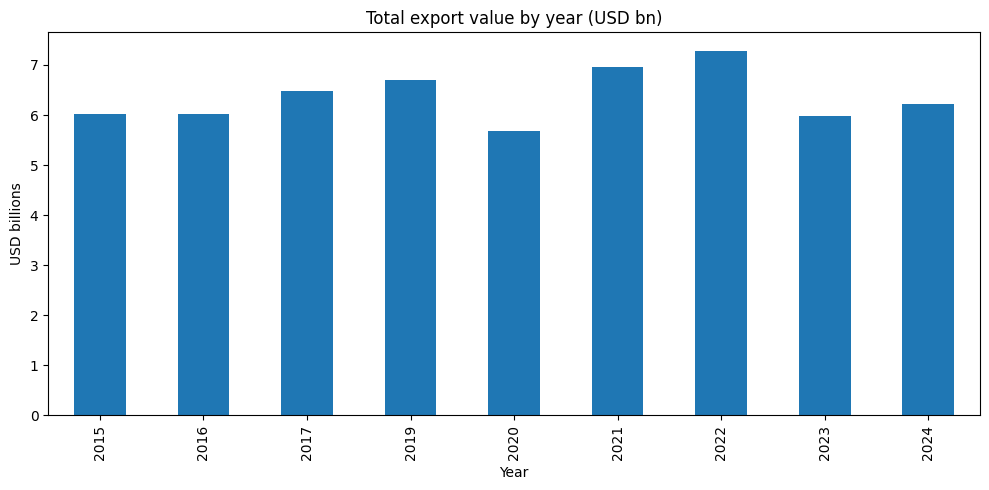

In [5]:
yearly = clean.groupby("year")["export_value_usd"].sum() / 1e9
ax = yearly.plot(kind="bar", title="Total export value by year (USD bn)")
ax.set_ylabel("USD billions")
ax.set_xlabel("Year")
plt.axvline  # placeholder no-op so the 2018 gap is visually obvious as a missing bar
plt.tight_layout()
plt.show()

## 5. Sector and product split

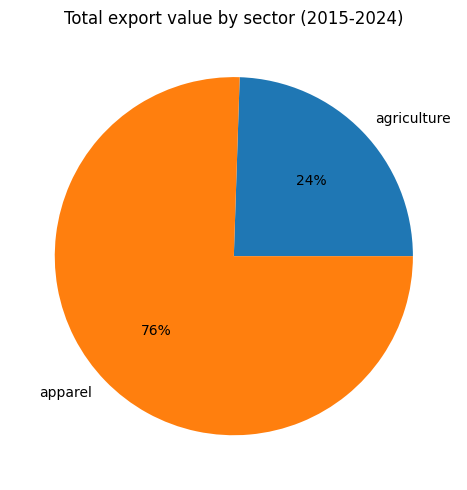

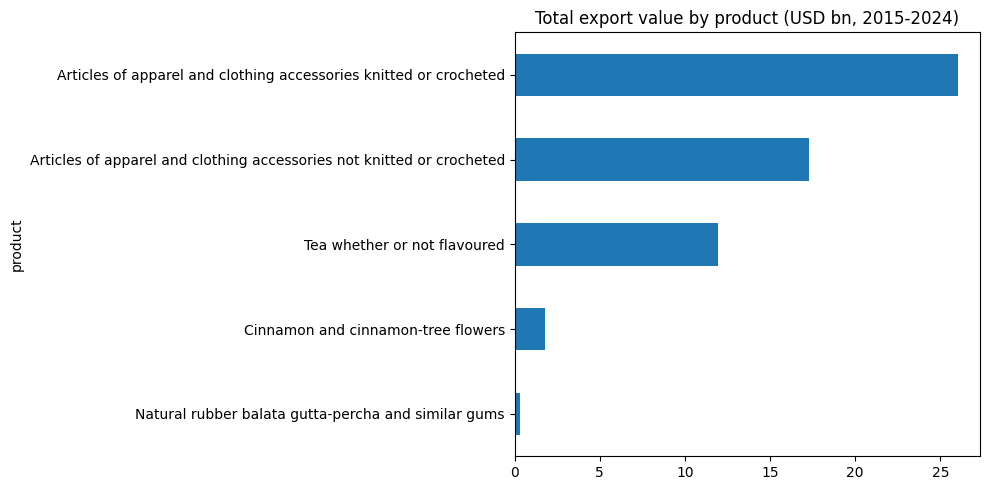

In [6]:
sector_totals = clean.groupby("sector")["export_value_usd"].sum() / 1e9
sector_totals.plot(kind="pie", autopct="%1.0f%%", ylabel="", title="Total export value by sector (2015-2024)")
plt.tight_layout()
plt.show()

product_totals = clean.groupby("product")["export_value_usd"].sum().sort_values() / 1e9
product_totals.plot(kind="barh", title="Total export value by product (USD bn, 2015-2024)")
plt.tight_layout()
plt.show()

## 6. Product trend over time (agriculture vs. apparel)

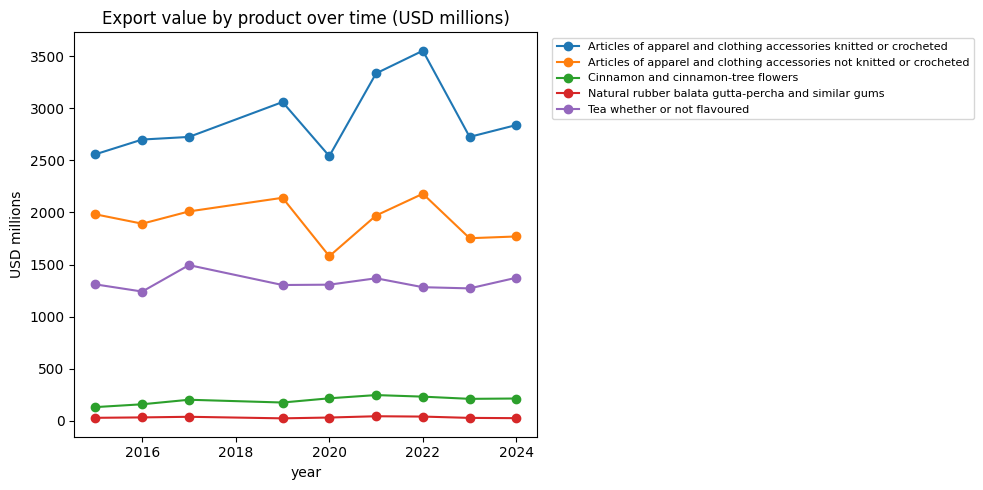

In [7]:
pivot = clean.pivot_table(index="year", columns="product", values="export_value_usd", aggfunc="sum") / 1e6
ax = pivot.plot(marker="o", title="Export value by product over time (USD millions)")
ax.set_ylabel("USD millions")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Top export destinations

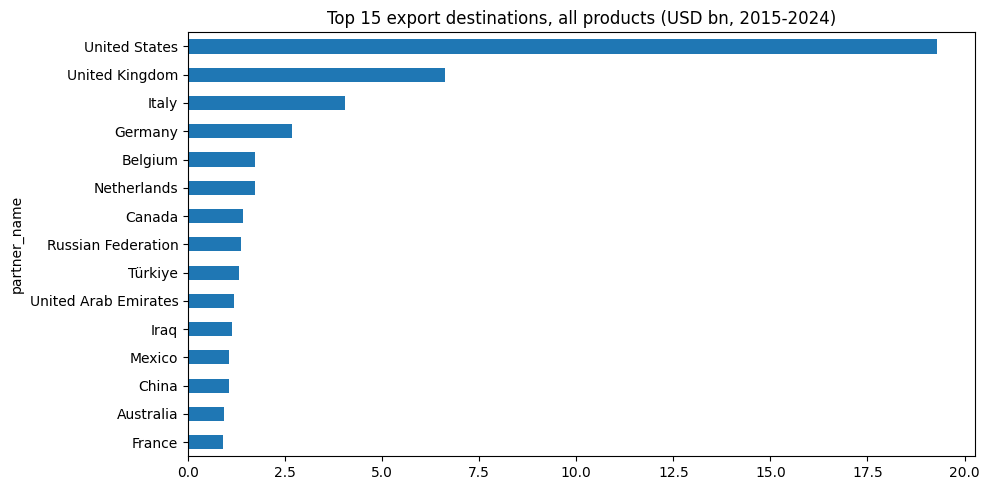

partner_name
United States           19.301790
United Kingdom           6.609144
Italy                    4.038270
Germany                  2.690406
Belgium                  1.735322
Netherlands              1.729389
Canada                   1.412088
Russian Federation       1.365882
Türkiye                  1.301498
United Arab Emirates     1.186901
Iraq                     1.135876
Mexico                   1.058273
China                    1.053736
Australia                0.922451
France                   0.894327
Name: export_value_usd, dtype: float64

In [8]:
top_partners = (
    clean.groupby("partner_name")["export_value_usd"].sum().sort_values(ascending=False).head(15) / 1e9
)
ax = top_partners.plot(kind="barh", title="Top 15 export destinations, all products (USD bn, 2015-2024)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
top_partners

## 8. Top destination per product

In [9]:
for product, group in clean.groupby("product"):
    top = group.groupby("partner_name")["export_value_usd"].sum().sort_values(ascending=False).head(5)
    print(f"\n{product}")
    print((top / 1e6).round(1).to_string(header=False))


Articles of apparel and clothing accessories knitted or crocheted
United States     10859.0
United Kingdom     3615.2
Italy              2323.8
Germany            1441.9
Belgium            1186.7

Articles of apparel and clothing accessories not knitted or crocheted
United States     7849.8
United Kingdom    2872.9
Italy             1638.8
Germany            885.4
Netherlands        509.4

Cinnamon and cinnamon-tree flowers
Mexico           743.5
United States    257.6
Peru             187.6
Colombia          83.8
Ecuador           73.5

Natural rubber balata gutta-percha and similar gums
Pakistan    59.6
Japan       38.9
Germany     26.8
Viet Nam    20.2
China       19.9

Tea whether or not flavoured
Russian Federation           1262.7
Türkiye                      1226.0
Iraq                         1135.8
Iran, Islamic Republic of     881.9
United Arab Emirates          781.8
